# Testing the draft 2D tile plot (`team/new_graphics/tile.py`)

This notebook exercises `make_tile()`, the draft implementation of the new 2D
tile plot type. It is **not** wired into `.plot()` yet — this is for visually
checking the draft before integration.

The tile plot draws a grid of filled cells colored by how often each cell
occurred. It handles **two discrete variables** *and* the **mixed case** — one
discrete axis, one continuous axis:

- A **discrete** axis gets one labeled cell per distinct value (no binning) —
  the one 2D view a histogram can't give.
- A **continuous** axis is split into equal-width bins, the same way `hist2d`
  bins, and labeled like a numeric histogram axis.

`make_tile` detects which axes are continuous automatically (float → continuous,
everything else → discrete) and bins whichever one it is — x, y, or neither.
Continuous × continuous data is still routed to `hist2d` / `density2d` instead.

**How to run:** open this notebook from the `team/new_graphics/new_graphics_demos/`
folder using the `symbulate` conda environment, then Run All.

**What to look for in every plot:**
- A grid of filled cells in **viridis** (the package's sequential colormap, from
  `symbulate.mplstyle` — no hardcoded `Blues`)
- Colorbar on the right, labeled "Relative Frequency" (or "Count" when
  `normalize=False`), placed with `make_axes_locatable`
- Color scale starts at 0, so a cell that never occurred reads as "no data"
- Colorbar ticks label both endpoints (0 and the peak value), evenly spaced;
  relative-frequency labels rounded to 3 decimals, counts shown as whole numbers
  (matching the density2d colorbar)
- **Discrete, whole-number** axis (a count-style variable): laid out on a real
  number line, one cell per possible value across the observed range (gaps show
  as empty columns) -- matplotlib's own locator picks nice, evenly spaced ticks,
  capped at `TILE_MAX_TICKS` (10), same as a continuous axis (see Section 7).
  **Categorical** discrete axis: compacted cells with an evenly spaced *subset*
  of labels (still horizontal) once it passes `TILE_MAX_TICKS` values.
  **Continuous** plot axis: automatic numeric ticks over the data range, like a
  histogram axis. Axis labels read "X" and "Y"
- Title reads "Tile Plot"; no reference grid (the mesh covers the axes)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# This notebook lives in <repo>/team/new_graphics/new_graphics_demos/.
REPO_ROOT = Path.cwd().parents[2]

# Make `import symbulate` find the dev copy in this repo (not an older
# installed copy in site-packages), and `from tile import ...` find
# the draft module one folder up.
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(Path.cwd().parent))

# The draft helper and its overlay-warning text
from tile import (
    make_tile,
    TILE_OVERLAY_WARNING,
    TILE_MAX_TICKS,
)

# Apply the global style file (viridis colormap, fonts, spines).
# Not yet wired into the package, so we apply it by hand here.
STYLE_PATH = REPO_ROOT / "symbulate" / "symbulate.mplstyle"
plt.style.use(STYLE_PATH)

rng = np.random.default_rng(7)


def visible_ticks(ax, axis="x"):
    """Tick locations actually within the axis's current view limits --
    get_xticks()/get_yticks() include candidate locations just outside the
    visible range that are never actually drawn."""
    lim = ax.get_xlim() if axis == "x" else ax.get_ylim()
    ticks = ax.get_xticks() if axis == "x" else ax.get_yticks()
    return np.array([t for t in ticks if lim[0] <= t <= lim[1]])

## 1. Two correlated discrete variables

`x` is Poisson(3); `y` tracks `x` plus a little integer noise. The bright cells
should fall along a diagonal band — the joint distribution read as a table of
shaded relative frequencies, one cell per (x, y) integer pair, brightest where
pairs occur most and dark purple where a pair never occurred.

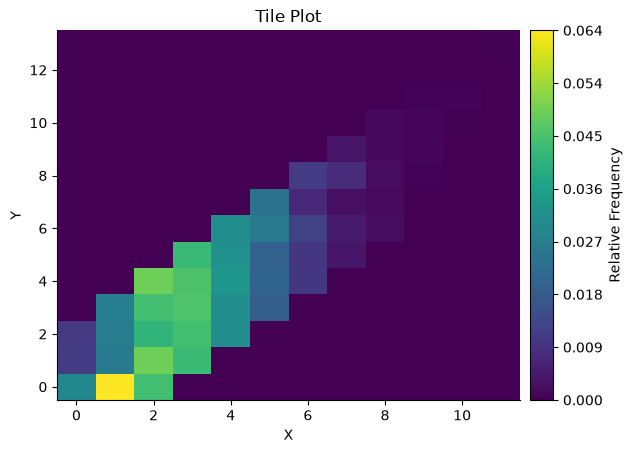

In [2]:
x = rng.poisson(3, 4000)
y = np.clip(x + rng.integers(-2, 3, 4000), 0, None)

ax = plt.gca()
make_tile(x, y, ax)
plt.show()  # title, axis labels, and colorbar are set by make_tile

## 2. Counts — `normalize=False`

The same picture as raw counts instead of relative frequencies; the colorbar
label switches to "Count" and the cell values sum to the number of simulations.

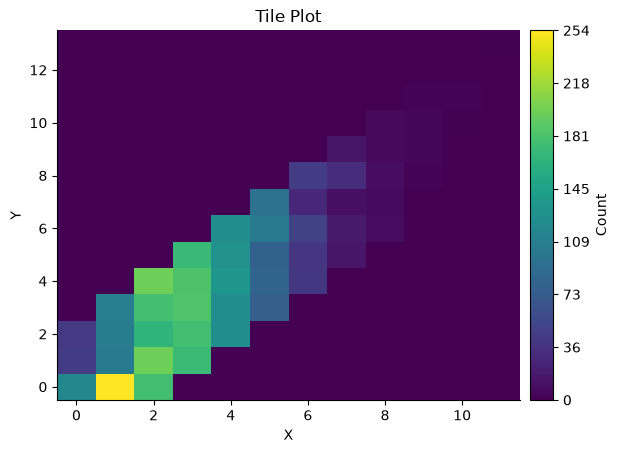

In [3]:
ax = plt.gca()
make_tile(x, y, ax, normalize=False)
plt.show()

## 3. Overlay behavior — the readability *warning* category

Per the overlay policy, two tile plots on the same axes is one of the designated
**warning** cases: the second tile still draws (overlay is never blocked outside
the `'marginal'` hard-error case), but its color scale competes with the first,
so a student-friendly warning prints below the plot.

The exact warning wording is still an open decision in `DECISIONS.md` — the text
printed here is the draft wording from `tile.py`.

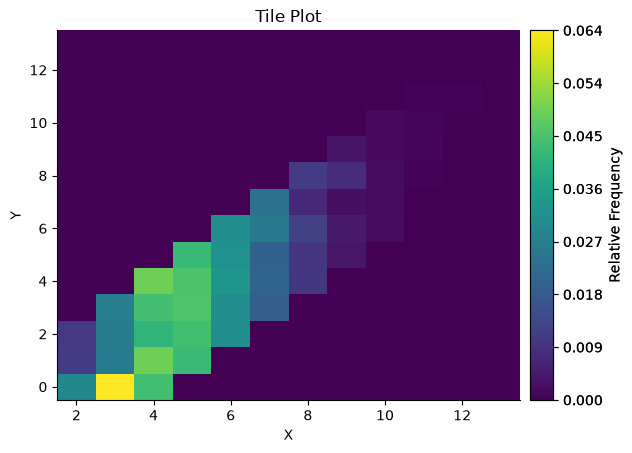

In [4]:
ax = plt.gca()
make_tile(x, y, ax)
make_tile(x + 2, y, ax)  # draws, and prints the warning
plt.show()

## 4. With real symbulate simulation data

The same plot, but the data comes from an actual `RV(...).sim(...)` call instead
of raw numpy: two independent Poisson variables, exactly the discrete × discrete
case the lookup table will route to a tile plot.

Caveat while testing today: creating `RVResults` currently calls `init_color()`,
which resets the color cycle to tab10, and importing `symbulate` switches the
matplotlib style back to the old stylesheet (both Phase 2 items) — so we re-apply
the style *after* importing and simulating.

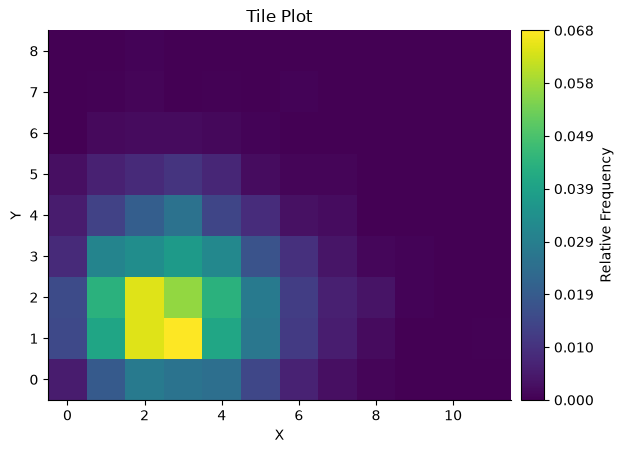

In [5]:
from symbulate import RV, Poisson

sims = RV(Poisson(3) * Poisson(2)).sim(4000)

plt.style.use(STYLE_PATH)  # re-apply: import + RVResults reset the style

arr = np.asarray(sims.results)
ax = plt.gca()
make_tile(arr[:, 0], arr[:, 1], ax)
plt.show()

## 5. Two variables with different numbers of distinct values

The tile grid does not need to be square. Here `X` takes 5 distinct values and
`Y` takes 10, so the plot is a 5-wide × 10-tall grid. `Y` grows with `X`
(`Y = 2X + a small step`), so the bright cells form a **diagonal staircase band**
climbing left to right — the joint pattern reads clearly even though the two axes
have different numbers of cells, and unobserved pairs stay dark. This is exactly
the discrete × discrete case where a single global bin count — as a 2D histogram
would use — makes no sense: the number of cells on each axis comes from that
variable's own distinct values.

Both `X` and `Y` are whole-number variables, so both are laid out on a real number
line (Section 7 covers this in depth) and matplotlib's own locator ticks each one
independently with a consistent, evenly spaced scale -- not necessarily the same
*count* of ticks on both axes.


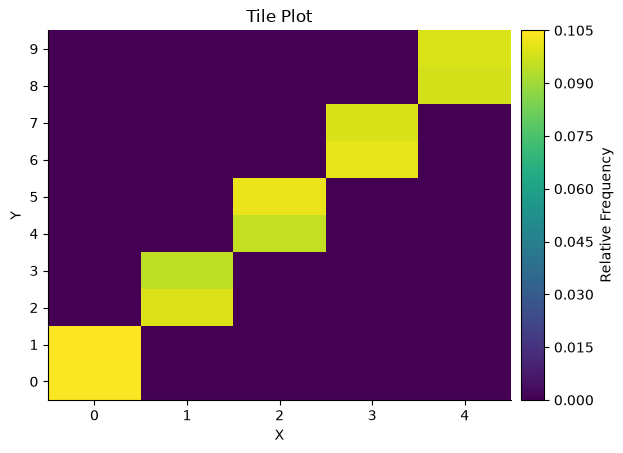

In [6]:
x5 = rng.integers(0, 5, 4000)            # 5 distinct values: 0, 1, 2, 3, 4
y10 = 2 * x5 + rng.integers(0, 2, 4000)  # 10 distinct values: 0..9, and Y grows with X

ax = plt.gca()
make_tile(x5, y10, ax)
plt.show()  # a 5-wide x 10-tall grid with a diagonal staircase band

## 6. Mixed data — one discrete axis, one continuous axis

This is the new capability. When one variable is continuous, `make_tile` bins
that axis into equal-width bins (the same binning `hist2d` uses) while the other
axis keeps one labeled cell per discrete level. Rows stay categorical; the
continuous axis reads like a numeric histogram axis.

Here `y` is discrete (Poisson, one row per level) and `x` is continuous (Normal,
correlated with the level so the bright cells drift right as `y` increases).
`x` is binned automatically — no argument needed — because it's float-valued.

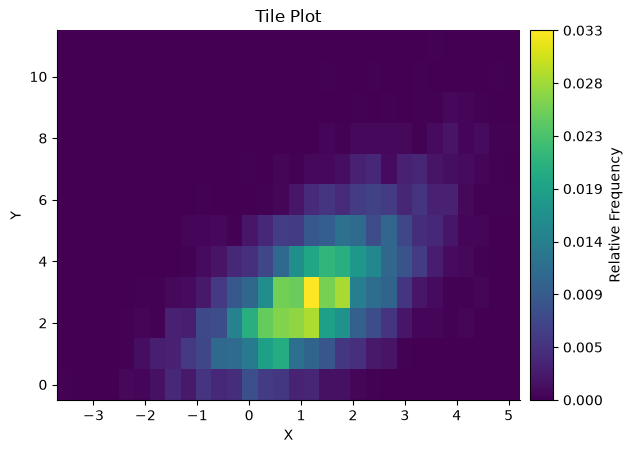

In [7]:
y_disc = rng.poisson(3, 4000)                       # discrete: one row per level
x_cont = rng.normal(0, 1, 4000) + 0.4 * y_disc      # continuous: correlated with y

ax = plt.gca()
make_tile(x_cont, y_disc, ax)  # x is float -> binned; y is int -> labeled rows
plt.show()  # rows = Poisson levels, columns = 30 Normal bins

### 6b. Same data, axes swapped

Binning follows whichever axis is continuous. Passing the same two variables in
the other order — continuous `y`, discrete `x` — bins the **y**-axis instead and
keeps `x` as labeled columns. You can also override the automatic detection with
`discrete_x=` / `discrete_y=`, and control the bin count with `bins=` (default 30).

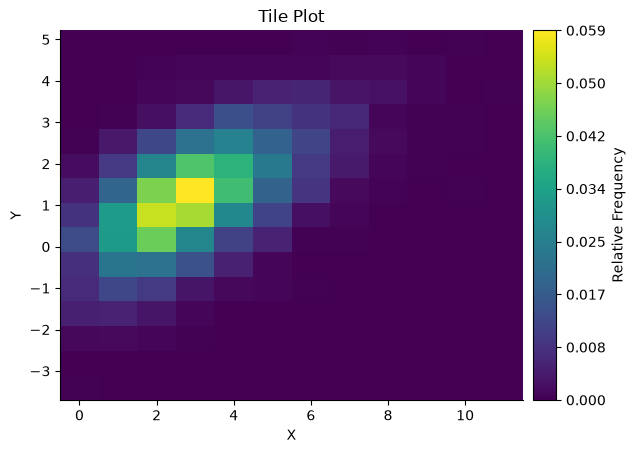

In [8]:
ax = plt.gca()
make_tile(y_disc, x_cont, ax, bins=15)  # now y is float -> binned (into 15); x labeled
plt.show()  # columns = Poisson levels, rows = 15 Normal bins

### 6c. `bins` only applies to a continuous axis

`bins` controls how a *continuous* axis is split. With two discrete variables
there is nothing to bin — every distinct value already gets its own cell — so
passing `bins` has no effect and `make_tile` warns and ignores it (the same
"argument has no effect here" style as `density2d`'s `levels=` without
`contour=True`). Here `x` and `y` are the two discrete Poisson variables from
Section 1.

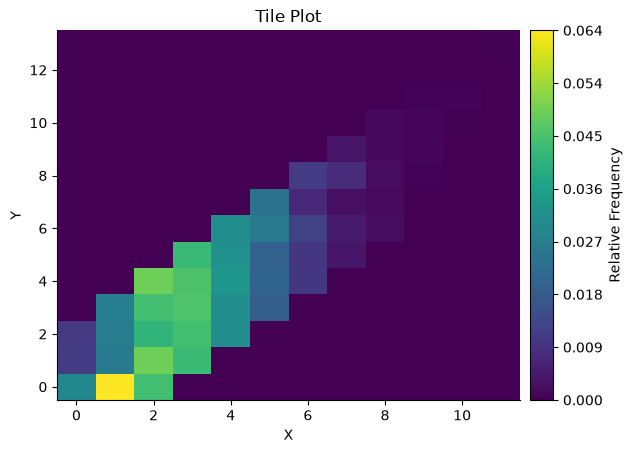

In [9]:
import warnings

# Two discrete variables + bins=: nothing to bin, so bins is ignored with a warning.
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    make_tile(x, y, plt.gca(), bins=15)  # x, y are the discrete Poisson vars from Section 1
for w in caught:
    print(f"{w.category.__name__}: {w.message}")
plt.show()  # still draws one cell per distinct value; bins had no effect

## 7. High-cardinality discrete axes — real-valued layout, not tick thinning

Before this fix, a discrete axis was laid out as compacted, rank-ordered cells --
cell 0, 1, 2, ... for the 1st, 2nd, 3rd *observed* distinct value -- with every
cell forced to carry its own tick label, no matter how many there were. That's
fine for a handful of levels (Section 1's Poisson(3) only has a few), but two
things go wrong once an axis reaches a few dozen distinct values, exactly what
happens with a wider Poisson, e.g. `Poisson(200)` (dozens of distinct values,
clustered around 200) or `Poisson(10)`:

1. **Overlapping labels.** Every observed value got its own forced tick, so the
   axis became a dense, unreadable smear.
2. **Uneven, inconsistent scale.** Even after thinning to a fixed number of
   labels, picking evenly spaced *ranks* doesn't give evenly spaced *values* --
   any gaps in the observed data (a count that never came up) make the labeled
   values jump by inconsistent amounts (e.g. 172, 178, 183, 191 -- jumps of 6, 5,
   8), instead of a clean, constant step like a normal numeric axis.

For a **whole-number** discrete axis (a count-style variable -- Binomial,
Poisson, a die roll, ...), `_setup_tile_axis` now lays it out on a real number
line instead: one unit-width cell for every whole number across the observed
range, not just the values that happened to occur. Two things follow:

- An unobserved-but-possible value (a count that never came up in this many
  simulations) shows as a visibly **empty column**, instead of silently
  vanishing (Section 7d).
- Because the axis is now a genuine number line, matplotlib's own numeric
  locator -- capped at `TILE_MAX_TICKS` (10) -- picks nice, **evenly spaced tick
  values with a constant step** (e.g. 170, 180, 190, 200, ...), the same as the
  continuous axis case, instead of a hand-picked subset of whichever values
  happened to occur.

One consequence: when both axes are discrete but have very different ranges,
each is now ticked *independently* for its own consistent scale, so the tick
*count* can differ between the two axes (Section 7c) -- a deliberate trade-off,
since forcing the same count on both would mean giving up a clean, constant
step on at least one of them. Categorical data, non-whole-number discrete data,
or a pathologically wide range (`TILE_MAX_GAP_FILL_RANGE`) still falls back to
the old compacted rank-index layout with thinned labels.


x distinct values observed: 84
y distinct values observed: 20


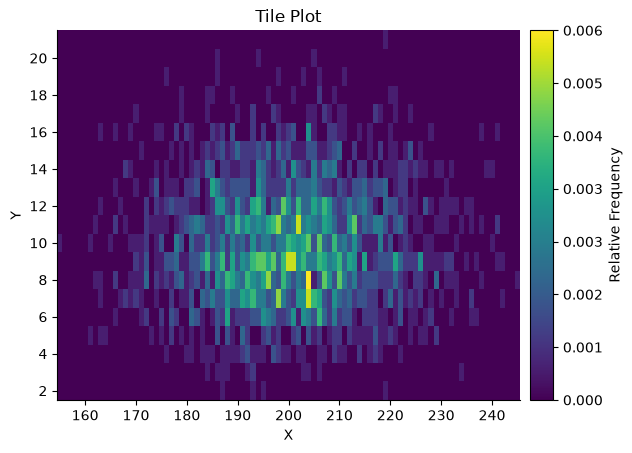

x ticks: [160. 170. 180. 190. 200. 210. 220. 230. 240.]
y ticks: [ 2.  4.  6.  8. 10. 12. 14. 16. 18. 20.]


In [10]:
x_wide = rng.poisson(200, 2000)  # dozens of distinct values, like the bug report
y_wide = rng.poisson(10, 2000)   # a couple dozen distinct values

print("x distinct values observed:", len(np.unique(x_wide)))
print("y distinct values observed:", len(np.unique(y_wide)))

ax = plt.gca()
make_tile(x_wide, y_wide, ax, discrete_x=True, discrete_y=True)
plt.show()

print("x ticks:", visible_ticks(ax, "x"))
print("y ticks:", visible_ticks(ax, "y"))


### 7b. Confirming: every possible value gets a cell, and the scale is consistent

The mesh's underlying array spans the *full* observed range on each axis --
every whole number from the minimum to the maximum gets its own column/row,
whether or not that exact count was ever observed -- so nothing is silently
dropped. And the tick values shown have a single, constant step between them
(printed below), unlike the old rank-based thinning's uneven jumps.


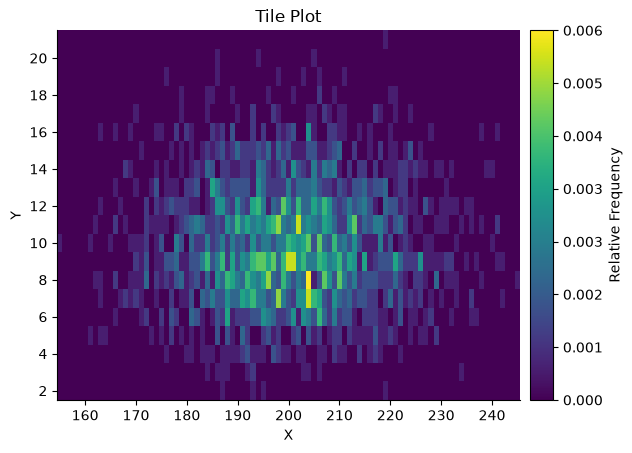

mesh shape (ny, nx): (20, 91)
x ticks shown: [160. 170. 180. 190. 200. 210. 220. 230. 240.] -- step(s): [10.]
y ticks shown: [ 2.  4.  6.  8. 10. 12. 14. 16. 18. 20.] -- step(s): [2.]
x label rotation: 0.0 (0 = horizontal)


In [11]:
ax = plt.gca()
mesh = make_tile(x_wide, y_wide, ax, discrete_x=True, discrete_y=True)
plt.show()

x_ticks, y_ticks = visible_ticks(ax, "x"), visible_ticks(ax, "y")
print("mesh shape (ny, nx):", mesh.get_array().shape)
print("x ticks shown:", x_ticks, "-- step(s):", np.unique(np.diff(x_ticks)))
print("y ticks shown:", y_ticks, "-- step(s):", np.unique(np.diff(y_ticks)))
print("x label rotation:", ax.get_xticklabels()[0].get_rotation(), "(0 = horizontal)")


### 7c. Low-cardinality axes are unaffected

A small die-roll-style axis (6 distinct, contiguous values, well under
`TILE_MAX_TICKS`) is still labeled with every value -- step of 1.


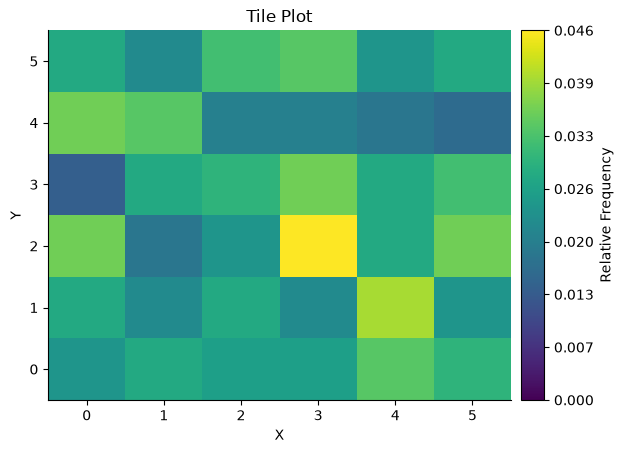

x distinct values: 6
x ticks shown: [0. 1. 2. 3. 4. 5.] = every distinct x value
x label rotation: 0.0 (0 = unrotated)


In [12]:
x_small = rng.integers(0, 6, 500)  # 6 distinct values -- well under the cap
y_small = rng.integers(0, 6, 500)

ax = plt.gca()
make_tile(x_small, y_small, ax)
plt.show()

print("x distinct values:", len(np.unique(x_small)))
print("x ticks shown:", visible_ticks(ax, "x"), "= every distinct x value")
print("x label rotation:", ax.get_xticklabels()[0].get_rotation(), "(0 = unrotated)")


### 7d. Mismatched axes each get their own consistent scale

`x_mismatch` has only 5 distinct values while `y_mismatch` has 30. Each axis
gets its *own* evenly spaced, constant-step ticks -- so the tick **count** can
now differ between axes (5 on `X`, several more on `Y`), rather than forcing an
identical count on both at the cost of an uneven scale on one of them.


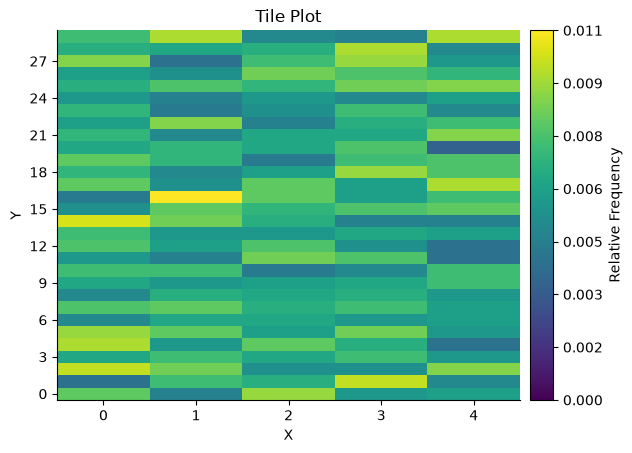

x distinct values: 5
y distinct values: 30
x ticks: [0. 1. 2. 3. 4.]
y ticks: [ 0.  3.  6.  9. 12. 15. 18. 21. 24. 27.]


In [13]:
x_mismatch = rng.integers(0, 5, 3000)   # 5 distinct values
y_mismatch = rng.integers(0, 30, 3000)  # 30 distinct values

ax = plt.gca()
make_tile(x_mismatch, y_mismatch, ax, discrete_x=True, discrete_y=True)
plt.show()

print("x distinct values:", len(np.unique(x_mismatch)))
print("y distinct values:", len(np.unique(y_mismatch)))
print("x ticks:", visible_ticks(ax, "x"))
print("y ticks:", visible_ticks(ax, "y"))


### 7e. An unobserved-but-possible value shows as an empty column

`x_gap` only ever takes the values 0, 1, 2, 4, 5 -- the value 3 never occurs.
Under the old rank-based layout, the axis would have silently shrunk to 5
columns (0, 1, 2, 4, 5 packed together, no gap visible). Now the axis spans
the full range 0-5 -- 6 columns -- with column 3 empty (dark, zero count),
honestly showing that 3 is a possible value this sample just didn't land on.


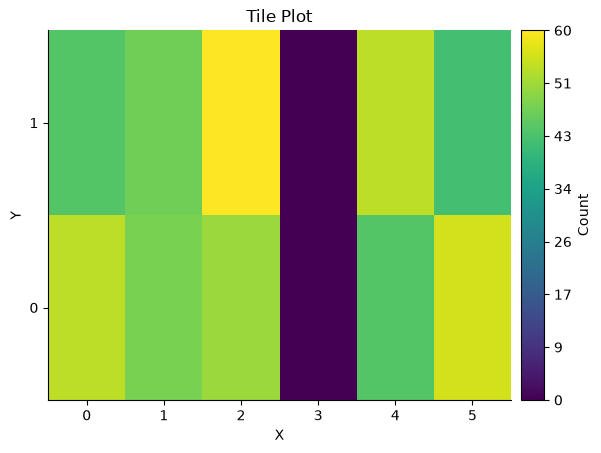

mesh shape (ny, nx): (2, 6) -- 6 x-columns, not 5
column for the unobserved value 3: [0. 0.] -- all zero


In [14]:
x_gap = np.random.choice([0, 1, 2, 4, 5], size=500)  # 3 never occurs
y_gap = np.random.choice([0, 1], size=500)

ax = plt.gca()
mesh = make_tile(x_gap, y_gap, ax, discrete_x=True, discrete_y=True, normalize=False)
plt.show()

print("mesh shape (ny, nx):", mesh.get_array().shape, "-- 6 x-columns, not 5")
print("column for the unobserved value 3:", mesh.get_array()[:, 3], "-- all zero")


## Verification checklist

- [ ] Section 1: one cell per distinct (x, y) integer pair; no binning
- [ ] Viridis colormap (not Blues); unobserved cells are dark purple, frequent cells yellow
- [ ] Colorbar on the right, sized proportionally to the axes
- [ ] Colorbar reads "Relative Frequency"; `normalize=False` switches it to "Count"
- [ ] Color scale starts at 0
- [ ] Colorbar ticks label both endpoints (0 and the peak), evenly spaced; relative-frequency labels have 3 decimals, counts are whole numbers
- [ ] Discrete axis: one tick per cell, labeled with the distinct value; axis labels "X"/"Y"; title "Tile Plot"
- [ ] No grid fragments around the mesh
- [ ] Section 2: relative frequencies sum to 1; counts sum to the number of simulations
- [ ] Single tile plot prints no warning
- [ ] Second tile plot on the same axes draws AND prints the readability warning
- [ ] Works on real `.sim()` output, not just numpy arrays
- [ ] Section 5: non-square grid — X with 5 values, Y with 10 — renders as a 5-wide × 10-tall grid
- [ ] Section 6: mixed data — discrete y stays labeled rows, continuous x is binned into 30 columns with a numeric axis
- [ ] Section 6b: swapping the arguments bins the y-axis instead; `bins=20` yields 20 bins on that axis
- [ ] Section 6c: passing `bins=` with two discrete variables prints a UserWarning and is ignored (still one cell per value)
- [ ] Mixed plots: the continuous axis shows automatic numeric ticks (not one tick per raw value)
- [ ] Section 7: a wide Poisson(200)/Poisson(10)-style axis is laid out on a real
  number line -- matplotlib's own locator picks evenly spaced, constant-step ticks
- [ ] Section 7b: the mesh spans the full observed range on each axis (nothing
  dropped); tick values shown have one constant step; labels stay horizontal
- [ ] Section 7c: low-cardinality axes (6 distinct values) are unaffected -- every
  value still labeled (step of 1), no rotation
- [ ] Section 7d: mismatched axis cardinalities (5 vs 30 distinct values) each get
  their own consistent, evenly spaced scale -- tick *counts* may now differ
- [ ] Section 7e: a value that's possible but never observed (3, skipped) shows as
  a visibly empty column -- the mesh has 6 columns, not 5
